### Topic
Breast cancer prediction from data

### Model
Losigtic Regression

### Data
sklearn - datasets - load_breast_cancer



In [100]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Load data
from sklearn.datasets import load_breast_cancer
cancer_data = load_breast_cancer()


In [101]:
# check feature names
print(cancer_data["feature_names"])

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [102]:
# check label names
print(cancer_data["target_names"])

['malignant' 'benign']


In [103]:
# check feature and label
print("feature data : ", cancer_data["data"][0])
print("label : ", cancer_data["target"][0])

feature data :  [1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
 1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
 6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
 1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
 4.601e-01 1.189e-01]
label :  0


In [104]:
# data EDA
data, target = cancer_data["data"], cancer_data["target"]
df = pd.DataFrame(data, columns=cancer_data["feature_names"])
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [105]:
# check label population
pd.Series(target).value_counts()

,count
1,357
0,212


(array([212.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 357.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

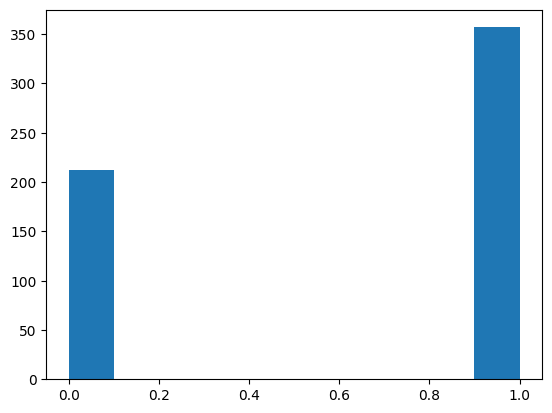

In [106]:
# plot histogram
plt.hist(target)

Text(0, 0.5, 'label')

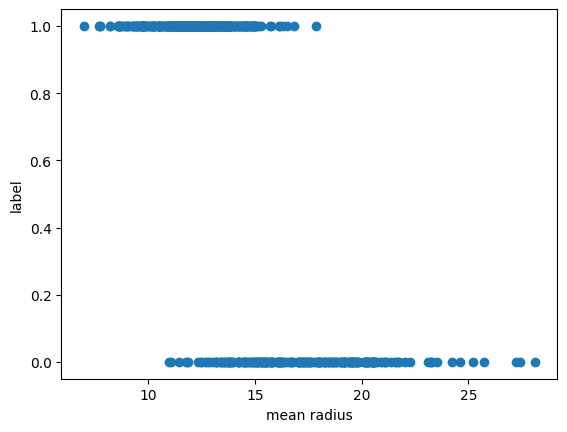

In [107]:
# plot label vs mean radius
plt.scatter(x=data[:,0], y=target)
plt.xlabel("mean radius")
plt.ylabel("label")

In [108]:
# Split data
from sklearn.model_selection import train_test_split
train_data, test_data, train_target, test_target = train_test_split( data, target, train_size=0.7, random_state=42)
print("train size : ", len(train_data))
print("test  size : ", len(test_data))

train size :  398
test  size :  171


### Try linear regression

In [109]:
# define and train
from sklearn.linear_model import LinearRegression
linear_regressor = LinearRegression()
linear_regressor.fit(train_data, train_target)
train_pred = linear_regressor.predict(train_data)
test_pred = linear_regressor.predict(test_data)

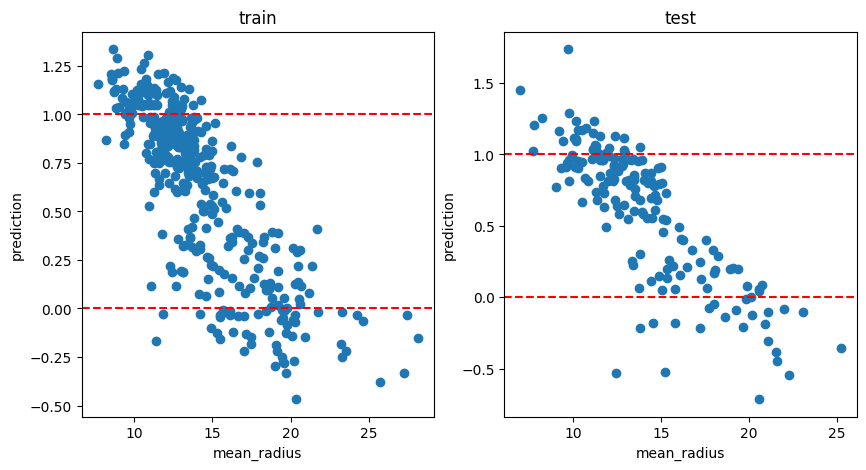

In [110]:
# plot the linear regressio prediction
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
preds = [
  ("train", train_data, train_pred),
  ("test", test_data, test_pred),
]
for idx, (name, dt, pred) in enumerate(preds) :
  ax = axes[idx]
  ax.scatter(x=dt[:,0], y=pred)
  ax.axhline(0, color="red", linestyle="--")
  ax.axhline(1, color="red", linestyle="--")
  ax.set_xlabel("mean_radius")
  ax.set_ylabel("prediction")
  ax.set_title(name)


In [111]:
# Evaluation finding the best threshold
from sklearn.metrics import auc, roc_curve
fpr, tpr, threshold = roc_curve(train_target, train_pred)
auroc = auc(fpr, tpr)

Text(0, 0.5, 'tpr')

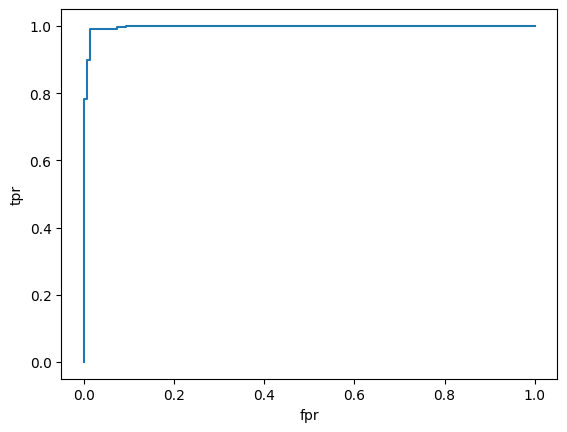

In [112]:
# plot auroc
plt.plot(fpr, tpr)
plt.xlabel("fpr")
plt.ylabel("tpr")

In [113]:
J = tpr - fpr
best_threshold = threshold[ np.argmax(J) ]
print("the best threshold : ", best_threshold)

the best threshold :  0.6002936908147198


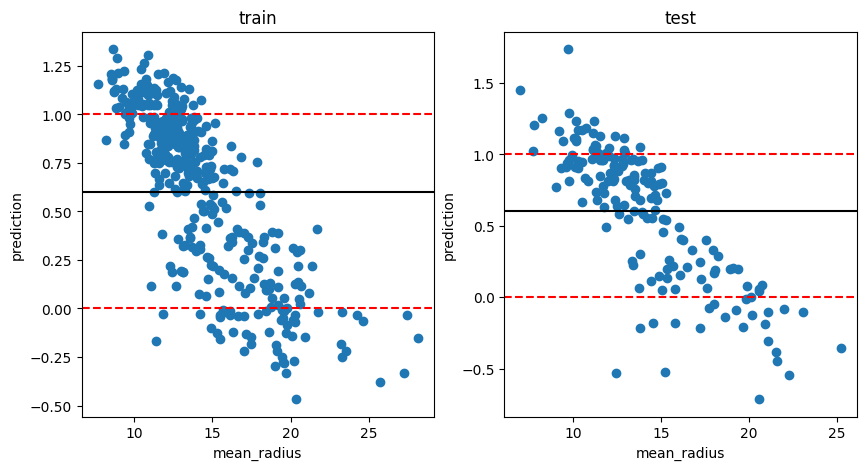

In [114]:
# plot the linear regressio prediction with the best threshold
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
preds = [
  ("train", train_data, train_pred),
  ("test", test_data, test_pred),
]
for idx, (name, dt, pred) in enumerate(preds) :
  ax = axes[idx]
  ax.scatter(x=dt[:,0], y=pred)
  ax.axhline(0, color="red", linestyle="--")
  ax.axhline(1, color="red", linestyle="--")
  ax.axhline(best_threshold, color="black", linestyle="-")

  ax.set_xlabel("mean_radius")
  ax.set_ylabel("prediction")
  ax.set_title(name)

In [115]:
# map the prediction values to {0, 1}
train_pred_label = list(map(int, train_pred > best_threshold))
test_pred_label = list(map(int, test_pred > best_threshold))

# calculate the accurary
from sklearn.metrics import accuracy_score
linear_train_accuracy = accuracy_score(train_target, train_pred_label)
linear_test_accuracy = accuracy_score(test_target, test_pred_label)

print(f"Train Acc is : {linear_train_accuracy:.4f}")
print(f"Test  Acc is : {linear_test_accuracy:.4f}")


Train Acc is : 0.9874
Test  Acc is : 0.9532


### Try logistic regression

In [116]:
# data regularization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaler.fit(train_data)
StandardScaler(copy=True, with_mean=True, with_std=True)

scaled_train_data = scaler.transform(train_data)
scaled_test_data = scaler.transform(test_data)

In [117]:
# load the model and fit
from sklearn.linear_model import LogisticRegression
logit_regressor = LogisticRegression()
logit_regressor.fit(scaled_train_data, train_target)

LogisticRegression()

In [118]:
# prediction "predict", and "predict_proba"
train_pred = logit_regressor.predict(scaled_train_data)
test_pred = logit_regressor.predict(scaled_test_data)
train_pred_logit = logit_regressor.predict_proba(scaled_train_data)
test_pred_logit = logit_regressor.predict_proba(scaled_test_data)

Text(0, 0.5, 'tpr')

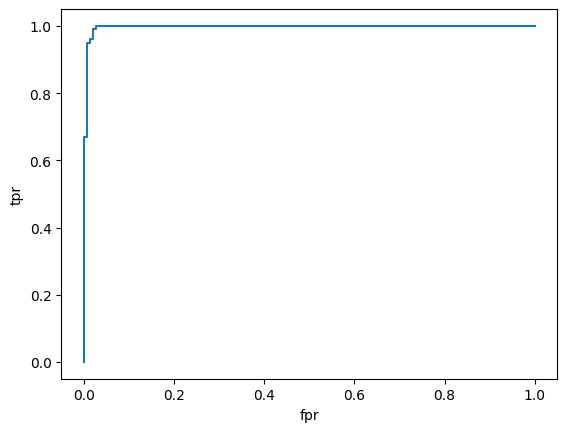

In [119]:
# evaluation  "predict_proba"
train_pred_logit = train_pred_logit[:,1]
test_pred_logit = test_pred_logit[:,1]

from sklearn.metrics import auc, roc_curve
fpr, tpr, threshold = roc_curve(train_target, train_pred_logit)
auroc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("fpr")
plt.ylabel("tpr")


In [120]:
J = tpr - fpr
best_threshold = threshold[ np.argmax(J) ]
print("the best threshold : ", best_threshold)

the best threshold :  0.4542718002393179


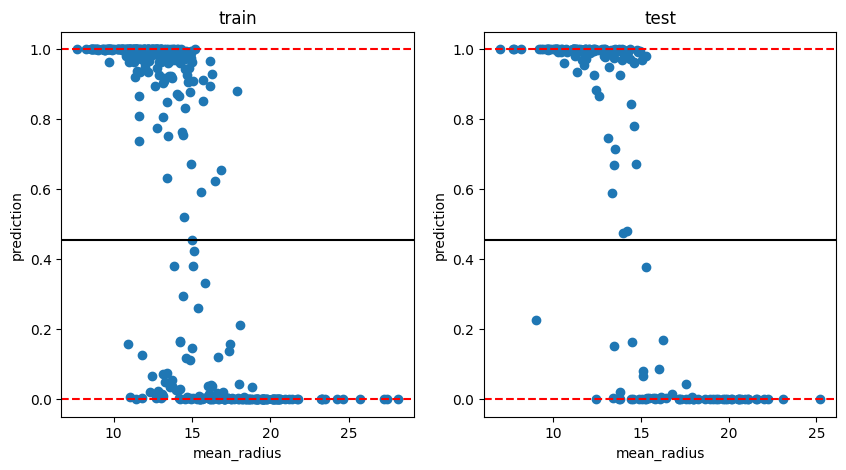

In [122]:
# plot the logistic regression prediction with the best threshold
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
preds = [
  ("train", train_data, train_pred_logit),
  ("test", test_data, test_pred_logit),
]
for idx, (name, dt, pred) in enumerate(preds) :
  ax = axes[idx]
  ax.scatter(x=dt[:,0], y=pred)
  ax.axhline(0, color="red", linestyle="--")
  ax.axhline(1, color="red", linestyle="--")
  ax.axhline(best_threshold, color="black", linestyle="-")

  ax.set_xlabel("mean_radius")
  ax.set_ylabel("prediction")
  ax.set_title(name)

In [123]:
# map the prediction values to {0, 1}
train_pred_label = list(map(int, train_pred > best_threshold))
test_pred_label = list(map(int, test_pred > best_threshold))

# calculate the accurary
from sklearn.metrics import accuracy_score
proba_train_accuracy = accuracy_score(train_target, train_pred_label)
proba_test_accuracy = accuracy_score(test_target, test_pred_label)

print(f"Train Acc is : {proba_train_accuracy:.4f}")
print(f"Test  Acc is : {proba_test_accuracy:.4f}")

Train Acc is : 0.9874
Test  Acc is : 0.9825


In [125]:
# evaluation  "predict"
train_accuracy = accuracy_score(train_target, train_pred)
test_accuracy = accuracy_score(test_target, test_pred)
print(f"Train Acc is : {train_accuracy:.4f}")
print(f"Test  Acc is : {test_accuracy:.4f}")


Train Acc is : 0.9874
Test  Acc is : 0.9825


### Summary
 - Linear Regression

 Train Accuracy : 98.74

 Test  Accuracy : 95.32


- Logistic Regression w/ probability

 Train Accuracy : 98.74

 Test  Accuracy : 98.25

- Logistic Regression w/ 0 or 1

 Train Accuracy : 98.74

 Test  Accuracy : 98.25
